In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from worldcup.tournament import load_teams, get_groups, get_group_matches
from worldcup.simulator import GroupStageSimulator
from worldcup.algorithms.poisson import PoissonGoalModel, _poisson_pmf
from worldcup.algorithms.womens_elo import WomensEloRatingModel

sns.set_theme(style='whitegrid', palette='muted')

# ── Configure model here ──────────────────────────────────────────────────────
rating_model = WomensEloRatingModel()
predictor = PoissonGoalModel(rating_model, base_lambda=1.3, alpha=0.3, max_ratio=10.0)
N_SIMULATIONS = 20_000
SEED = 42
# ─────────────────────────────────────────────────────────────────────────────

teams = load_teams()
groups = get_groups(teams)
flag_map  = {t.name: t.flag  for t in teams}
group_map = {t.name: t.group for t in teams}

mens_rankings   = pd.read_csv('../data/rankings.csv').set_index('country')
womens_rankings = pd.read_csv('../data/womens_elo.csv').set_index('country')

# Women's Elo model

## Algorithm

This model rates each team using its **FIFA/Coca-Cola Women's World Ranking** Elo
points, taken from [inside.fifa.com/fifa-world-ranking/women](https://inside.fifa.com/fifa-world-ranking/women)
(June 2026 live ranking, 198 teams).

**Hypothesis:** does the strength of a country's *women's* national team predict how
its *men's* team will fare at WC 2026?

### Rating

$$\text{rating}(t) = \text{WomensEloPoints}(t)$$

Qatar has no FIFA-ranked senior women's national team, so it falls back to a rating of
**400.0** — below the lowest-ranked team in the dataset (Mauritius, 433.66).

The rating feeds into the Poisson goal model via the rating ratio **and its inverse**:
$$\lambda_h = \lambda_0 \cdot \text{ratio}^{\alpha}, \qquad \lambda_a = \frac{\lambda_0}{\text{ratio}^{\alpha}}, \qquad \text{ratio} = \frac{\text{rating}(\text{home})}{\text{rating}(\text{away})}$$
with $\lambda_0 = 1.3$, $\alpha = 0.3$, max ratio cap = 10.

### Component breakdown — all WC teams

In [2]:
def womens_rank(name):
    if name in womens_rankings.index:
        return int(womens_rankings.loc[name, 'womens_fifa_ranking'])
    return None

rows = []
for t in sorted(teams, key=lambda t: rating_model.rate(t), reverse=True):
    w_rank = womens_rank(t.name)
    w_elo  = rating_model.rate(t)
    m_rank = int(mens_rankings.loc[t.name, 'fifa_ranking'])
    m_pts  = float(mens_rankings.loc[t.name, 'fifa_points'])
    rows.append({
        'Team':             f'{flag_map[t.name]} {t.name}',
        "Women's rank":     w_rank if w_rank is not None else '—',
        "Women's Elo":      round(w_elo, 2),
        "Men's FIFA rank":  m_rank,
        "Men's FIFA pts":   round(m_pts, 1),
        'Δ (Women − Men)':  round(w_elo - m_pts, 1),
    })

breakdown = pd.DataFrame(rows)
breakdown.style \
    .hide(axis='index') \
    .background_gradient(subset="Women's Elo",    cmap='RdYlGn', vmin=400, vmax=2100) \
    .background_gradient(subset="Men's FIFA pts", cmap='RdYlGn', vmin=700, vmax=1900) \
    .background_gradient(subset='Δ (Women − Men)', cmap='RdBu',  vmin=-600, vmax=600)

Team,Women's rank,Women's Elo,Men's FIFA rank,Men's FIFA pts,Δ (Women − Men)
🇪🇸 Spain,1,2105.360000,2,1874.700000,230.700000
🇺🇸 United States,2,2057.920000,17,1671.200000,386.700000
🇩🇪 Germany,3,2028.990000,10,1735.800000,293.200000
🏴󠁧󠁢󠁥󠁮󠁧󠁿 England,4,2027.130000,4,1827.000000,200.100000
🇯🇵 Japan,5,1998.830000,18,1661.600000,337.200000
🇫🇷 France,6,1983.840000,3,1870.700000,113.100000
🇧🇷 Brazil,7,1976.730000,6,1765.900000,210.900000
🇸🇪 Sweden,8,1937.940000,38,1509.800000,428.200000
🇨🇦 Canada,9,1936.900000,30,1559.500000,377.400000
🇳🇱 Netherlands,10,1911.750000,8,1753.600000,158.200000


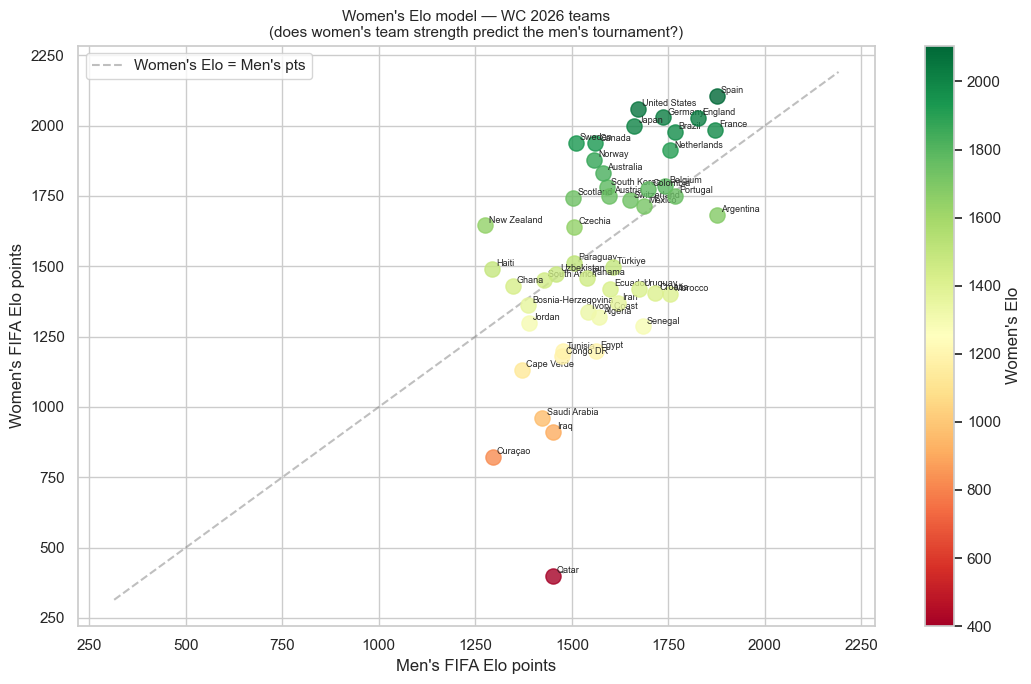

In [3]:
# Scatter: men's FIFA points vs women's Elo, colour = women's Elo
fig, ax = plt.subplots(figsize=(11, 7))

w_elos = [rating_model.rate(t) for t in teams]
norm = plt.Normalize(min(w_elos), max(w_elos))
cmap = plt.cm.RdYlGn

for t in teams:
    m_pts = float(mens_rankings.loc[t.name, 'fifa_points'])
    w_elo = rating_model.rate(t)
    ax.scatter(m_pts, w_elo, s=120, alpha=0.8, color=cmap(norm(w_elo)), zorder=3)
    ax.annotate(t.name, (m_pts, w_elo), fontsize=6.5,
                xytext=(3, 2), textcoords='offset points')

lo = min(min(ax.get_xlim()), min(ax.get_ylim()))
hi = max(max(ax.get_xlim()), max(ax.get_ylim()))
ax.plot([lo, hi], [lo, hi], ls='--', color='grey', alpha=0.5, zorder=1, label="Women's Elo = Men's pts")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Women's Elo")

ax.set_xlabel("Men's FIFA Elo points")
ax.set_ylabel("Women's FIFA Elo points")
ax.set_title("Women's Elo model — WC 2026 teams\n(does women's team strength predict the men's tournament?)", fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

### Example prediction — Spain vs Qatar

Spain: Women's Elo 2105.36 (rank 1)
Qatar: Women's Elo 400.00 (no FIFA-ranked women's team — fallback)
λ_home = 2.140,  λ_away = 0.790


Outcome,Probability
🇪🇸 Spain win,68.4%
Draw,19.0%
🇶🇦 Qatar win,12.6%


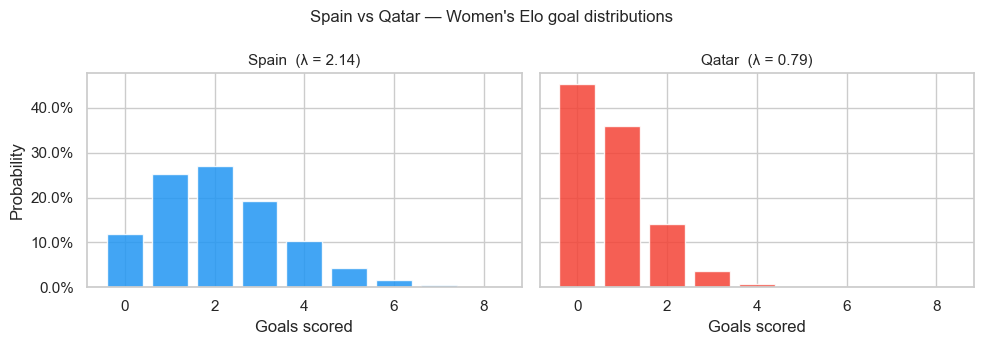

In [4]:
example_home = next(t for t in teams if t.name == 'Spain')
example_away = next(t for t in teams if t.name == 'Qatar')

w_h = rating_model.rate(example_home)
w_a = rating_model.rate(example_away)
λ_h, λ_a = predictor.lambdas(example_home, example_away)
p_home, p_draw, p_away = predictor.predict(example_home, example_away)

print(f"{example_home.name}: Women's Elo {w_h:.2f} (rank {womens_rank(example_home.name)})")
print(f"{example_away.name}: Women's Elo {w_a:.2f} (no FIFA-ranked women's team — fallback)")
print(f'λ_home = {λ_h:.3f},  λ_away = {λ_a:.3f}')

example_df = pd.DataFrame([
    {'Outcome': f'{example_home.flag} {example_home.name} win', 'Probability': p_home},
    {'Outcome': 'Draw',                                          'Probability': p_draw},
    {'Outcome': f'{example_away.flag} {example_away.name} win', 'Probability': p_away},
])
display(example_df.style.hide(axis='index')
        .format({'Probability': '{:.1%}'})
        .bar(subset='Probability', color='#90CAF9', vmin=0, vmax=1))

max_g = 8
goals = np.arange(0, max_g + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
axes[0].bar(goals, [_poisson_pmf(g, λ_h) for g in goals], color='#2196F3', alpha=0.85)
axes[0].set_title(f'{example_home.name}  (λ = {λ_h:.2f})', fontsize=11)
axes[0].set_xlabel('Goals scored'); axes[0].set_ylabel('Probability')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
axes[1].bar(goals, [_poisson_pmf(g, λ_a) for g in goals], color='#F44336', alpha=0.85)
axes[1].set_title(f'{example_away.name}  (λ = {λ_a:.2f})', fontsize=11)
axes[1].set_xlabel('Goals scored')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
fig.suptitle(f'{example_home.name} vs {example_away.name} — Women\'s Elo goal distributions', fontsize=12)
plt.tight_layout(); plt.show()

---

## Group stage qualification probabilities

In [5]:
sim = GroupStageSimulator(predictor, n=N_SIMULATIONS, seed=SEED)
results = sim.run(groups)
df = results.to_dataframe()

df['flag']       = df['team'].map(flag_map)
df['group']      = df['team'].map(group_map)
df['Team']       = df['flag'] + ' ' + df['team']
df['womens_elo'] = df['team'].map(lambda n: round(rating_model.rate(next(t for t in teams if t.name == n)), 1))

qual_table = df[['group', 'Team', 'womens_elo', 'p_qualify', 'p_group_winner', 'p_runner_up', 'p_best_third', 'p_eliminated']].copy()
qual_table.columns = ['Group', 'Team', "Women's Elo", 'Qualify', '1st', '2nd', 'Best 3rd', 'Eliminated']

qual_table.style \
    .hide(axis='index') \
    .format({c: '{:.1%}' for c in ['Qualify', '1st', '2nd', 'Best 3rd', 'Eliminated']}) \
    .background_gradient(subset='Qualify',     cmap='RdYlGn',   vmin=0, vmax=1) \
    .background_gradient(subset='Eliminated',  cmap='RdYlGn_r', vmin=0, vmax=1) \
    .background_gradient(subset="Women's Elo", cmap='RdYlGn',   vmin=400, vmax=2100)

Group,Team,Women's Elo,Qualify,1st,2nd,Best 3rd,Eliminated
B,🇨🇦 Canada,1936.900000,84.9%,38.0%,30.4%,16.5%,15.1%
B,🇨🇭 Switzerland,1734.200000,82.4%,33.6%,31.1%,17.7%,17.6%
H,🇪🇸 Spain,2105.400000,81.6%,40.2%,27.4%,13.9%,18.4%
E,🇩🇪 Germany,2029.000000,81.2%,39.3%,28.0%,13.9%,18.8%
I,🇫🇷 France,1983.800000,78.7%,34.9%,28.1%,15.7%,21.3%
I,🇳🇴 Norway,1878.500000,76.4%,32.4%,28.1%,15.9%,23.6%
L,🏴󠁧󠁢󠁥󠁮󠁧󠁿 England,2027.100000,76.3%,34.5%,26.6%,15.1%,23.7%
B,🇧🇦 Bosnia-Herzegovina,1361.100000,74.4%,24.4%,29.2%,20.8%,25.6%
C,🇧🇷 Brazil,1976.700000,73.5%,31.4%,26.4%,15.7%,26.5%
D,🇺🇸 United States,2057.900000,73.3%,31.0%,26.7%,15.6%,26.7%


---

## Match predictions

In [6]:
match_rows = []
for group_name, group_teams in sorted(groups.items()):
    for home, away in get_group_matches(group_teams):
        λ_h, λ_a = predictor.lambdas(home, away)
        p_hw, p_d, p_aw = predictor.predict(home, away)
        match_rows.append({
            'Group':      group_name,
            'Home':       f'{home.flag} {home.name}',
            'Away':       f'{away.flag} {away.name}',
            'λ home':     round(λ_h, 3),
            'λ away':     round(λ_a, 3),
            'Home win %': p_hw,
            'Draw %':     p_d,
            'Away win %': p_aw,
        })

matches_df = pd.DataFrame(match_rows)
matches_df.style \
    .hide(axis='index') \
    .format({c: '{:.1%}' for c in ['Home win %', 'Draw %', 'Away win %']}) \
    .background_gradient(subset='Home win %', cmap='Blues',  vmin=0, vmax=1) \
    .background_gradient(subset='Away win %', cmap='Reds',   vmin=0, vmax=1) \
    .background_gradient(subset='Draw %',     cmap='Greens', vmin=0, vmax=1)

Group,Home,Away,λ home,λ away,Home win %,Draw %,Away win %
A,🇲🇽 Mexico,🇿🇦 South Africa,1.367000,1.236000,39.9%,26.3%,33.8%
A,🇲🇽 Mexico,🇰🇷 South Korea,1.285000,1.315000,36.1%,26.4%,37.5%
A,🇲🇽 Mexico,🇨🇿 Czechia,1.317000,1.283000,37.6%,26.4%,36.0%
A,🇿🇦 South Africa,🇰🇷 South Korea,1.223000,1.382000,33.1%,26.3%,40.6%
A,🇿🇦 South Africa,🇨🇿 Czechia,1.253000,1.349000,34.6%,26.3%,39.1%
A,🇰🇷 South Korea,🇨🇿 Czechia,1.332000,1.269000,38.3%,26.4%,35.3%
B,🇨🇦 Canada,🇧🇦 Bosnia-Herzegovina,1.445000,1.169000,43.4%,26.0%,30.6%
B,🇨🇦 Canada,🇶🇦 Qatar,2.087000,0.810000,66.9%,19.6%,13.4%
B,🇨🇦 Canada,🇨🇭 Switzerland,1.344000,1.258000,38.8%,26.4%,34.8%
B,🇧🇦 Bosnia-Herzegovina,🇶🇦 Qatar,1.877000,0.900000,60.3%,22.1%,17.6%
